# EDA: Dual-Track Dataset Exploration (HaluEval + LibreEval)

This notebook treats HaluEval and LibreEval as two complementary dataset tracks for hallucination detection.

- **Track A — HaluEval**: paired factual vs hallucinated generations across QA, dialogue, and summarization.
- **Track B — LibreEval**: RAG-grounded, real-world hallucination data with hallucination-type annotations and domain metadata.

The analyses are separated so each dataset's structure, balance, and modeling implications are clear before comparing them.

**Project-focused questions:**
- How often do examples exceed DistilBERT (512) vs ModernBERT (8192) context limits?
- How does class balance differ across tracks and splits?
- Which splits are best suited for training vs robustness evaluation?

In [17]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datasets import load_from_disk
from transformers import AutoTokenizer

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR = os.path.join(ROOT, 'data', 'raw', 'halueval')
print('Data root:', DATA_DIR)

# Tokenizer used for length diagnostics relative to model context limits
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

Data root: /Users/sergiomandujano/Documents/long-context-hallucination-detection/data/raw/halueval


## Track A — HaluEval

### A1. Load splits

In [18]:
qa_ds   = load_from_disk(os.path.join(DATA_DIR, 'qa'))
dial_ds = load_from_disk(os.path.join(DATA_DIR, 'dialogue'))
summ_ds = load_from_disk(os.path.join(DATA_DIR, 'summarization'))

# Each is a DatasetDict with a single 'data' split
qa   = qa_ds['data'].to_pandas()
dial = dial_ds['data'].to_pandas()
summ = summ_ds['data'].to_pandas()

print(f'qa          : {len(qa):>6} rows  columns: {list(qa.columns)}')
print(f'dialogue    : {len(dial):>6} rows  columns: {list(dial.columns)}')
print(f'summarization: {len(summ):>6} rows  columns: {list(summ.columns)}')

qa          :  10000 rows  columns: ['knowledge', 'question', 'right_answer', 'hallucinated_answer']
dialogue    :  10000 rows  columns: ['knowledge', 'dialogue_history', 'right_response', 'hallucinated_response']
summarization:  10000 rows  columns: ['document', 'right_summary', 'hallucinated_summary']


### A2. Schema inspection

In [19]:
for name, df in [('QA', qa), ('Dialogue', dial), ('Summarization', summ)]:
    print(f'=== {name} ===')
    display(df.head(2))
    print()

=== QA ===


,knowledge,question,right_answer,hallucinated_answer
0,Arthur's Magazine (1844–1846) was an American literary periodical published in Philadelphia in the 19th century.First for Women is a woman's magaz...,Which magazine was started first Arthur's Magazine or First for Women?,Arthur's Magazine,First for Women was started first.
1,"The Oberoi family is an Indian family that is famous for its involvement in hotels, namely through The Oberoi Group.The Oberoi Group is a hotel co...",The Oberoi family is part of a hotel company that has a head office in what city?,Delhi,The Oberoi family's hotel company is based in Mumbai.



=== Dialogue ===


,knowledge,dialogue_history,right_response,hallucinated_response
0,Iron Man is starring Robert Downey Jr.Robert Downey Jr. starred in Zodiac (Crime Fiction Film)Zodiac (Crime Fiction Film) is starring Jake Gyllenhaal,[Human]: Do you like Iron Man [Assistant]: Sure do! Robert Downey Jr. is a favorite. [Human]: Yes i like him too did you know he also was in Zodia...,I like crime fiction! Didn't know RDJ was in there. Jake Gyllenhaal starred as well.,"I'm not a fan of crime movies, but I did know that RDJ starred in Zodiac with Tom Hanks."
1,The Secret Life of Bees has genre Teen drama. Teen drama has examples: A Walk to RememberA Walk to Remember is produced by Hunt LowryHunt Lowry pr...,"[Human]: Could you recommend any books like The Secret Life of Bees? [Assistant]: Yes, its a great teen book, have you heard about A walk to remem...",yes and he also produced White Oleander and it was released in 1999,"No, I don't think Hunt Lowry was involved in A Walk to Remember. However, he produced the movie adaptation of the popular novel, White Oleander, w..."



=== Summarization ===


,document,right_summary,hallucinated_summary
0,"Marseille, France (CNN)The French prosecutor leading an investigation into the crash of Germanwings Flight 9525 insisted Wednesday that he was not...","Marseille prosecutor says ""so far no videos were used in the crash investigation"" despite media reports. Journalists at Bild and Paris Match are ""...",A video showing the final moments of Germanwings Flight 9525 has been recovered by investigators from the wreckage site. Marseille prosecutor Bric...
1,"The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdi...",Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June. Israel and the United States oppos...,"The International Criminal Court has officially accepted Palestine as its 123rd member, despite objections from Israel and the United States. This..."


### A3. Unpack into (input_text, label) and check label balance

Each row contains a **right** response (label=0) and a **hallucinated** response (label=1).
We explode each row into two labelled examples.

**Input text construction per split:**
- **qa**: `knowledge [SEP] question [SEP] answer`
- **dialogue**: `knowledge [SEP] dialogue_history [SEP] response`
- **summarization**: `document [SEP] summary`

In [20]:
SEP = ' [SEP] '

def unpack(df, context_cols, right_col, hall_col, split_name):
    ctx = df[context_cols].agg(SEP.join, axis=1)
    factual      = pd.DataFrame({'input_text': ctx + SEP + df[right_col], 'label': 0, 'split': split_name})
    hallucinated = pd.DataFrame({'input_text': ctx + SEP + df[hall_col],  'label': 1, 'split': split_name})
    return pd.concat([factual, hallucinated], ignore_index=True)

df_qa   = unpack(qa,   ['knowledge', 'question'],         'right_answer',       'hallucinated_answer',    'qa')
df_dial = unpack(dial, ['knowledge', 'dialogue_history'], 'right_response',      'hallucinated_response',  'dialogue')
df_summ = unpack(summ, ['document'],                      'right_summary',       'hallucinated_summary',   'summarization')

all_df = pd.concat([df_qa, df_dial, df_summ], ignore_index=True)
print(f'Total labelled examples: {len(all_df):,}')
print(all_df.groupby(['split', 'label']).size().rename('count'))

Total labelled examples: 60,000
split          label
dialogue       0        10000
               1        10000
qa             0        10000
               1        10000
summarization  0        10000
               1        10000
Name: count, dtype: int64


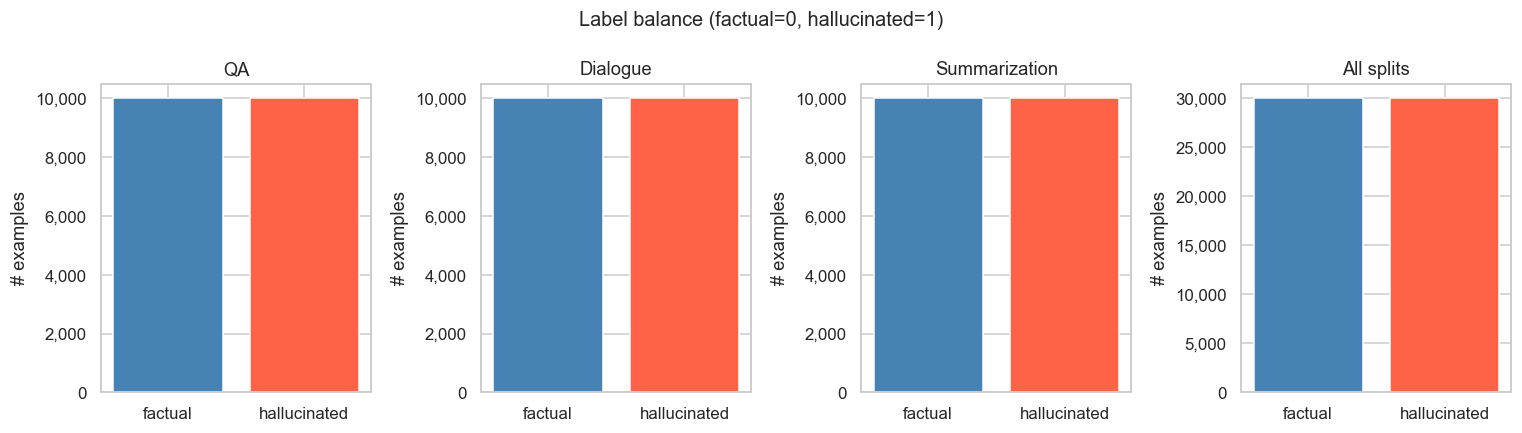

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

label_names = {0: 'factual', 1: 'hallucinated'}

for ax, (name, sub) in zip(axes[:3], [('QA', df_qa), ('Dialogue', df_dial), ('Summarization', df_summ)]):
    counts = sub['label'].value_counts().sort_index()
    ax.bar([label_names[i] for i in counts.index], counts.values, color=['steelblue', 'tomato'])
    ax.set_title(name)
    ax.set_ylabel('# examples')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

counts_all = all_df['label'].value_counts().sort_index()
axes[3].bar([label_names[i] for i in counts_all.index], counts_all.values, color=['steelblue', 'tomato'])
axes[3].set_title('All splits')
axes[3].set_ylabel('# examples')
axes[3].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

fig.suptitle('Label balance (factual=0, hallucinated=1)', fontsize=13)
plt.tight_layout()
plt.show()

### A4. Word-count and token-length distributions

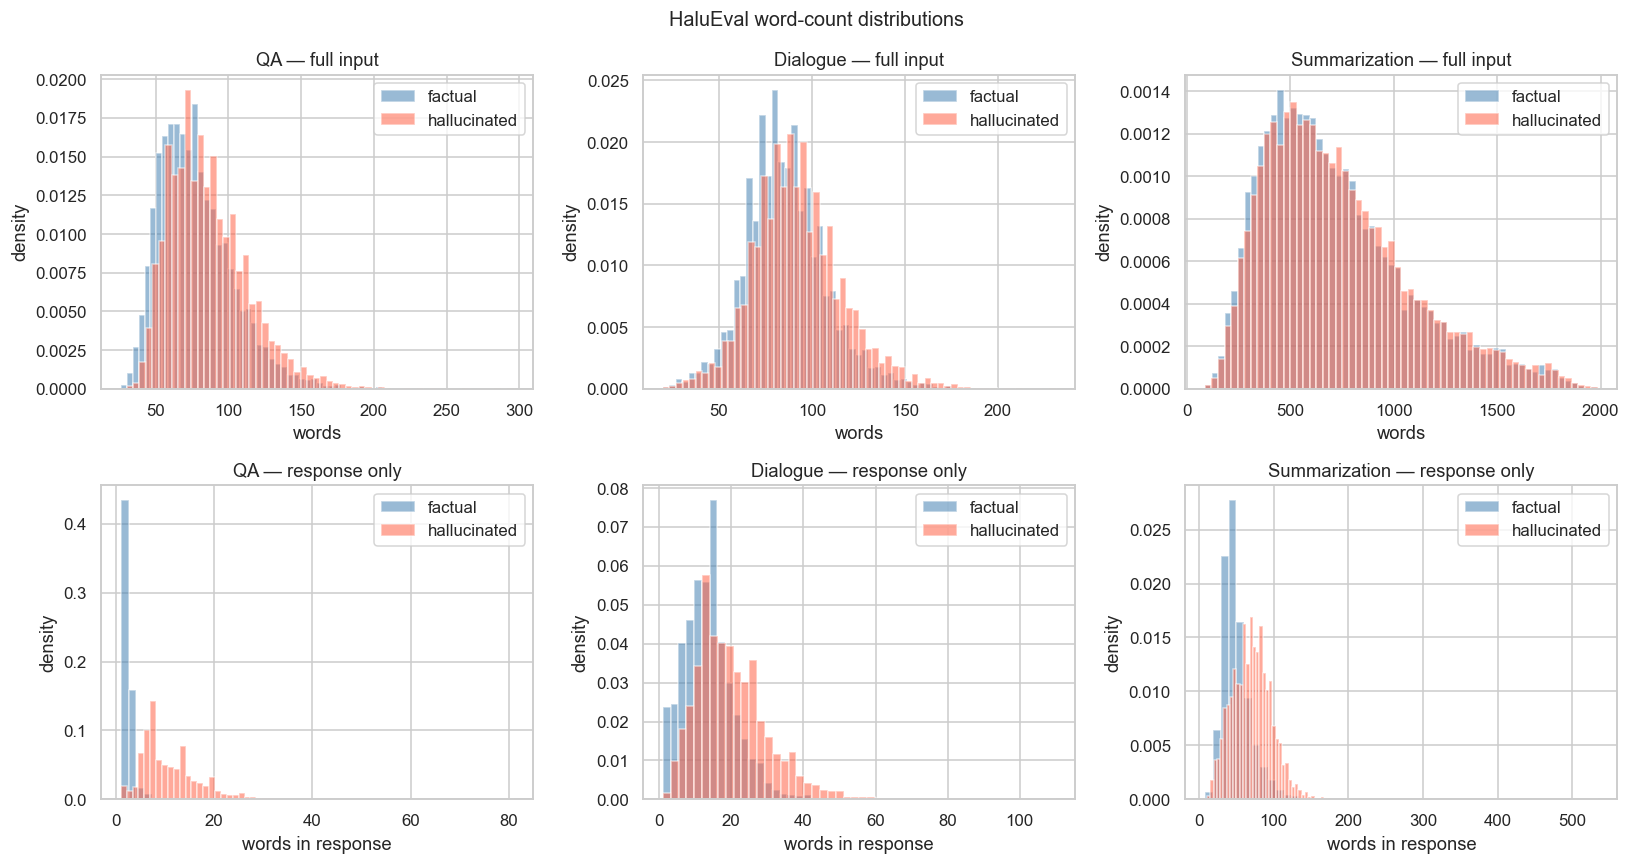

                       count   mean    std   min    25%    50%    75%     max
split         label                                                          
dialogue      0      10000.0   86.1   21.9  20.0   72.0   84.0   98.0   227.0
              1      10000.0   92.6   24.1  20.0   77.0   91.0  106.0   231.0
qa            0      10000.0   77.6   25.3  26.0   59.0   74.0   92.0   271.0
              1      10000.0   86.4   26.9  30.0   66.0   82.0  102.0   296.0
summarization 0      10000.0  714.8  350.3  89.0  451.0  645.0  906.0  1984.0
              1      10000.0  735.3  353.1  87.0  468.0  670.0  933.0  1987.0


In [22]:
for df_split in [df_qa, df_dial, df_summ]:
    df_split['word_count'] = df_split['input_text'].str.split().str.len()
all_df = pd.concat([df_qa, df_dial, df_summ], ignore_index=True)

splits = [
    ('QA',            df_qa,   qa,   'right_answer',   'hallucinated_answer'),
    ('Dialogue',      df_dial, dial, 'right_response',  'hallucinated_response'),
    ('Summarization', df_summ, summ, 'right_summary',   'hallucinated_summary'),
]

# Row 0: full input word count  |  Row 1: response-only word count
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for col, (name, sub, df_raw, right_col, hall_col) in enumerate(splits):
    for lbl, color, lab in [(0, 'steelblue', 'factual'), (1, 'tomato', 'hallucinated')]:
        sub[sub['label'] == lbl]['word_count'].plot.hist(
            ax=axes[0, col], bins=60, alpha=0.55, color=color, label=lab, density=True)
    axes[0, col].set_title(f'{name} — full input')
    axes[0, col].set_xlabel('words'); axes[0, col].set_ylabel('density'); axes[0, col].legend()

    r_len = df_raw[right_col].str.split().str.len()
    h_len = df_raw[hall_col].str.split().str.len()
    axes[1, col].hist(r_len, bins=50, alpha=0.55, density=True, color='steelblue', label='factual')
    axes[1, col].hist(h_len, bins=50, alpha=0.55, density=True, color='tomato',    label='hallucinated')
    axes[1, col].set_title(f'{name} — response only')
    axes[1, col].set_xlabel('words in response'); axes[1, col].set_ylabel('density'); axes[1, col].legend()

fig.suptitle('HaluEval word-count distributions', fontsize=13)
plt.tight_layout(); plt.show()
print(all_df.groupby(['split', 'label'])['word_count'].describe().round(1))

Token lengths (DistilBERT tokenizer, n=2000 sample per split):
  qa               median=107  p95=183  max=336  >512: 0.0%  >2048: 0.0%


Token indices sequence length is longer than the specified maximum sequence length for this model (1372 > 512). Running this sequence through the model will result in indexing errors


  dialogue         median=127  p95=185  max=256  >512: 0.0%  >2048: 0.0%
  summarization    median=855  p95=1910  max=2439  >512: 83.5%  >2048: 3.3%


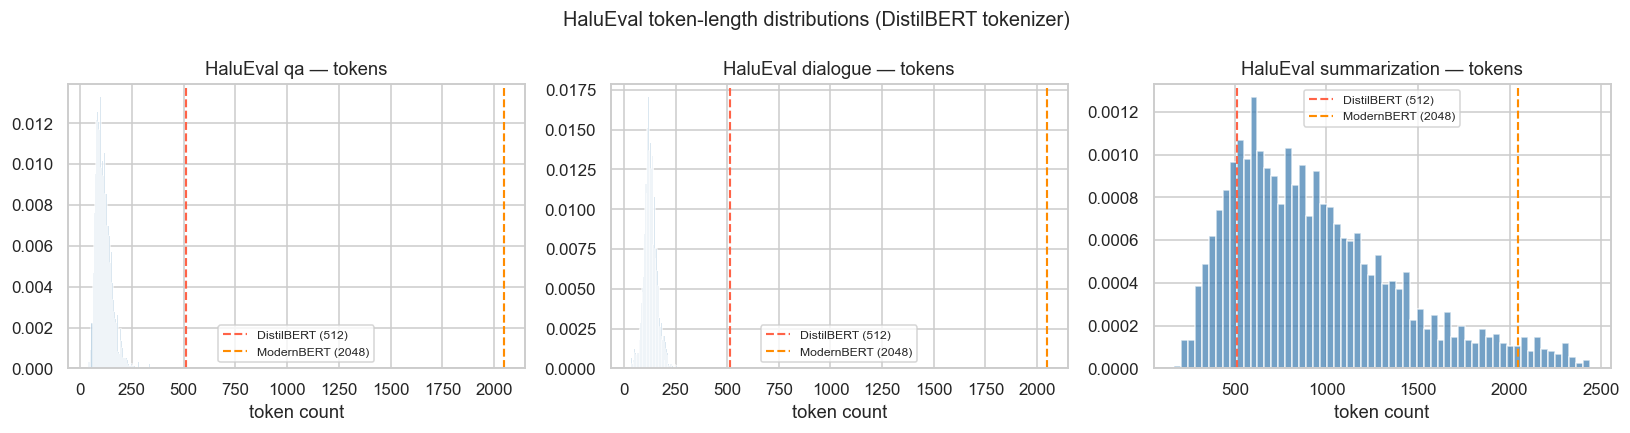

In [23]:
SAMPLE_N = 2000
print('Token lengths (DistilBERT tokenizer, n=2000 sample per split):')
tok_stats = {}
for name, sub in [('qa', df_qa), ('dialogue', df_dial), ('summarization', df_summ)]:
    texts = sub['input_text'].sample(min(SAMPLE_N, len(sub)), random_state=42).tolist()
    lens  = np.array([len(tokenizer.encode(t, add_special_tokens=True)) for t in texts])
    tok_stats[name] = lens
    print(f'  {name:15s}  median={np.median(lens):.0f}  p95={np.percentile(lens,95):.0f}  '
          f'max={lens.max()}  >512: {(lens>512).mean()*100:.1f}%  >2048: {(lens>2048).mean()*100:.1f}%')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, lens) in zip(axes, tok_stats.items()):
    ax.hist(lens, bins=60, color='steelblue', alpha=0.75, density=True)
    ax.axvline(512,  color='tomato',     linestyle='--', linewidth=1.4, label='DistilBERT (512)')
    ax.axvline(2048, color='darkorange', linestyle='--', linewidth=1.4, label='ModernBERT (2048)')
    ax.set_title(f'HaluEval {name} — tokens')
    ax.set_xlabel('token count')
    ax.legend(fontsize=8)

plt.suptitle('HaluEval token-length distributions (DistilBERT tokenizer)', fontsize=13)
plt.tight_layout(); plt.show()

### A5. Sample rows

In [24]:
pd.set_option('display.max_colwidth', 200)
print('=== QA — one paired example ===')
display(qa[['knowledge', 'question', 'right_answer', 'hallucinated_answer']].head(1))

print('\n=== Dialogue — one paired example ===')
display(dial[['knowledge', 'dialogue_history', 'right_response', 'hallucinated_response']].head(1))

print('\n=== Summarization — one paired example ===')
display(summ[['document', 'right_summary', 'hallucinated_summary']].head(1))

=== QA — one paired example ===


,knowledge,question,right_answer,hallucinated_answer
0,Arthur's Magazine (1844–1846) was an American literary periodical published in Philadelphia in the 19th century.First for Women is a woman's magazine published by Bauer Media Group in the USA.,Which magazine was started first Arthur's Magazine or First for Women?,Arthur's Magazine,First for Women was started first.



=== Dialogue — one paired example ===


,knowledge,dialogue_history,right_response,hallucinated_response
0,Iron Man is starring Robert Downey Jr.Robert Downey Jr. starred in Zodiac (Crime Fiction Film)Zodiac (Crime Fiction Film) is starring Jake Gyllenhaal,[Human]: Do you like Iron Man [Assistant]: Sure do! Robert Downey Jr. is a favorite. [Human]: Yes i like him too did you know he also was in Zodiac a crime fiction film.,I like crime fiction! Didn't know RDJ was in there. Jake Gyllenhaal starred as well.,"I'm not a fan of crime movies, but I did know that RDJ starred in Zodiac with Tom Hanks."



=== Summarization — one paired example ===


,document,right_summary,hallucinated_summary
0,"Marseille, France (CNN)The French prosecutor leading an investigation into the crash of Germanwings Flight 9525 insisted Wednesday that he was not aware of any video footage from on board the plan...","Marseille prosecutor says ""so far no videos were used in the crash investigation"" despite media reports. Journalists at Bild and Paris Match are ""very confident"" the video clip is real, an editor ...",A video showing the final moments of Germanwings Flight 9525 has been recovered by investigators from the wreckage site. Marseille prosecutor Brice Robin urged anyone who might have more footage t...


---
## Track B — LibreEval

LibreEval is analyzed as a separate track (not an append to HaluEval) because its construction and label semantics differ.

### B1. Load LibreEval files

Each row has `reference` (retrieved context), `input` (question), `output` (LLM answer), and `label` (`factual` / `hallucinated`).
The data comes from 10 real websites across technical, medical, legal, and science domains.

**Files used in this section:**
- `non_synthetic_hallucinations_english.csv` — real (non-synthetic) RAG responses
- `synthetic_hallucinations_english.csv` — synthetically augmented responses
- `balanced_hallucinations.csv` — pre-balanced tuning/train split
- `test.csv` — held-out tuning/test split

In [25]:
LIBRE_DIR = os.path.join(ROOT, "data", "raw", "libreval")

libre_ns   = pd.read_csv(os.path.join(LIBRE_DIR, "combined_datasets_for_evals", "non_synthetic_hallucinations_english.csv"))
libre_syn  = pd.read_csv(os.path.join(LIBRE_DIR, "combined_datasets_for_evals", "synthetic_hallucinations_english.csv"))
libre_train = pd.read_csv(os.path.join(LIBRE_DIR, "combined_datasets_for_tuning", "english_only", "balanced_hallucinations.csv"))
libre_test  = pd.read_csv(os.path.join(LIBRE_DIR, "combined_datasets_for_tuning", "english_only", "test.csv"))

for name, df in [("non_synthetic_eval", libre_ns), ("synthetic_eval", libre_syn),
                 ("tuning_train", libre_train), ("tuning_test", libre_test)]:
    print(f"{name:20s}: {len(df):>6} rows  columns: {list(df.columns[:6])} ...")

non_synthetic_eval  :  10871 rows  columns: ['reference', 'input', 'output', 'label', 'label_gpt-4o', 'explanation_gpt-4o'] ...
synthetic_eval      :  16366 rows  columns: ['reference', 'input', 'output', 'label', 'label_gpt-4o', 'explanation_gpt-4o'] ...
tuning_train        :  18254 rows  columns: ['reference', 'input', 'output', 'label', 'label_gpt-4o', 'explanation_gpt-4o'] ...
tuning_test         :   2739 rows  columns: ['reference', 'input', 'output', 'label', 'label_gpt-4o', 'explanation_gpt-4o'] ...


### B2. Schema — sample rows

In [26]:
pd.set_option("display.max_colwidth", 150)
print("=== non_synthetic_eval — sample row ===")
display(libre_ns[["reference", "input", "output", "label", "hallucination_type_realized", "question_type", "website"]].head(3))

=== non_synthetic_eval — sample row ===


,reference,input,output,label,hallucination_type_realized,question_type,website
0,"$validate stage checks streaming documents for\nconformity to a schema of expected ranges, values, or datatypes.",What is the purpose of the $validate stage in document processing?,"check streaming documents for conformity to a schema of expected ranges, values, or datatypes.",factual,NaN,Default question type,https://www.mongodb.com/docs/
1,"$validate stage checks streaming documents for\nconformity to a schema of expected ranges, values, or datatypes.",What is the purpose of the validate stage in streaming document processing?,"check streaming documents for conformity to a schema of expected ranges, values, or datatypes.",factual,NaN,Default question type,https://www.mongodb.com/docs/
2,"At the same time, you need continuous and instant insights into your digital business. With those insights your systems unlock higher efficiency a...",How can real-time insights improve business efficiency and profitability compared to using outdated data?,"Systems can make intelligent decisions and take actions on live data in real time, unlocking higher efficiency and profitability, instead of relyi...",factual,NaN,Default question type,https://www.mongodb.com/docs/


### B3. Label balance

> `NOT_PARSABLE` rows are excluded from modeling and should be dropped in the data loader.

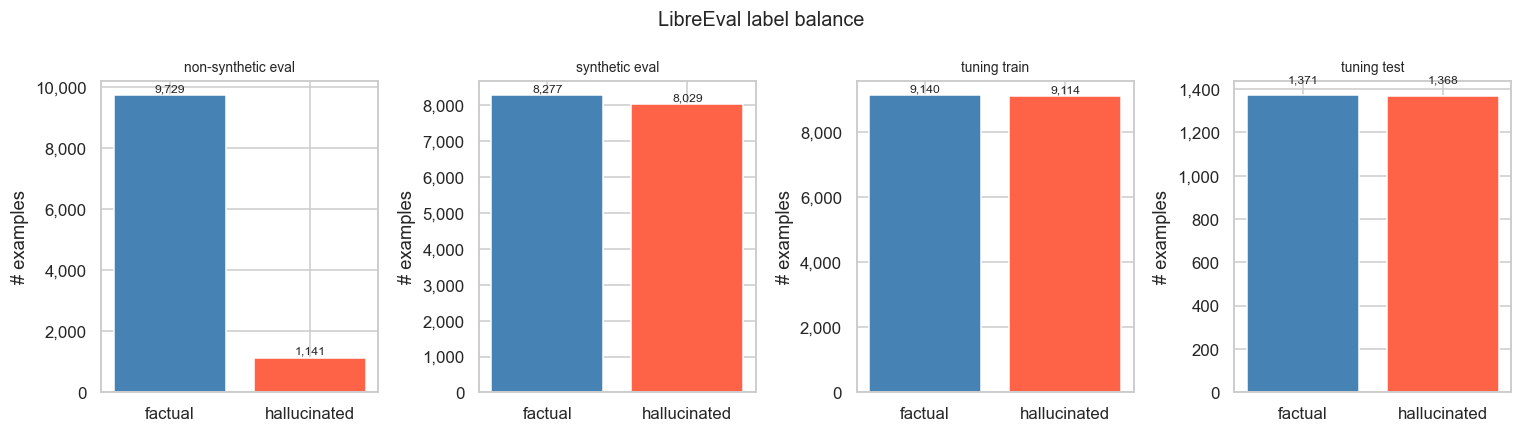

non_synthetic — NOT_PARSABLE dropped: 1
synthetic     — NOT_PARSABLE dropped: 60


In [27]:
# Drop NOT_PARSABLE before analysis
ns_clean  = libre_ns[libre_ns["label"].isin(["factual", "hallucinated"])].copy()
syn_clean = libre_syn[libre_syn["label"].isin(["factual", "hallucinated"])].copy()

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
subsets = [
    ("non-synthetic eval", ns_clean),
    ("synthetic eval",     syn_clean),
    ("tuning train",       libre_train),
    ("tuning test",        libre_test),
]
for ax, (name, sub) in zip(axes, subsets):
    counts = sub["label"].value_counts()
    ax.bar(counts.index, counts.values, color=["steelblue" if l == "factual" else "tomato" for l in counts.index])
    ax.set_title(name, fontsize=9)
    ax.set_ylabel("# examples")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    for bar, val in zip(ax.patches, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f"{val:,}", ha="center", va="bottom", fontsize=8)

fig.suptitle("LibreEval label balance", fontsize=13)
plt.tight_layout()
plt.show()

print(f"non_synthetic — NOT_PARSABLE dropped: {(libre_ns['label'] == 'NOT_PARSABLE').sum()}")
print(f"synthetic     — NOT_PARSABLE dropped: {(libre_syn['label'] == 'NOT_PARSABLE').sum()}")

### B4. Hallucination type breakdown

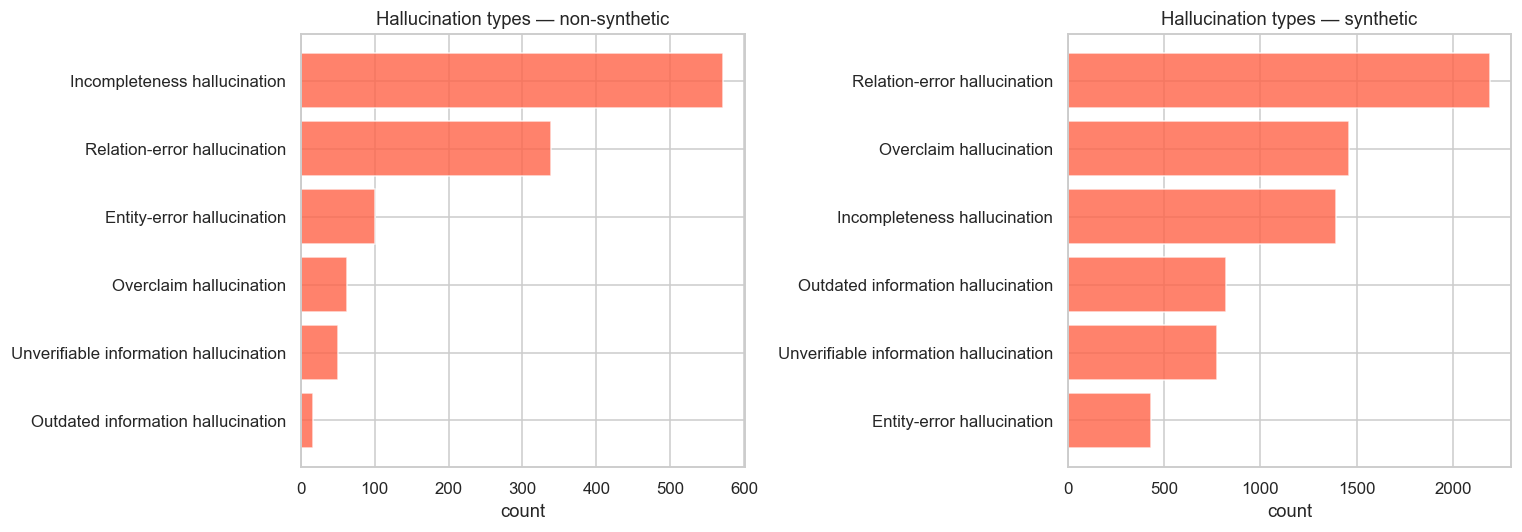

non-synthetic:
hallucination_type_realized
Incompleteness hallucination              572
Relation-error hallucination              339
Entity-error hallucination                101
Overclaim hallucination                    62
Unverifiable information hallucination     50
Outdated information hallucination         17
Name: count, dtype: int64

synthetic:
hallucination_type_realized
Relation-error hallucination              2194
Overclaim hallucination                   1461
Incompleteness hallucination              1393
Outdated information hallucination         822
Unverifiable information hallucination     773
Entity-error hallucination                 431
Name: count, dtype: int64


In [28]:
# Only hallucinated rows have a type label
hal_ns  = ns_clean[ns_clean["label"] == "hallucinated"]
hal_syn = syn_clean[syn_clean["label"] == "hallucinated"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, sub) in zip(axes, [("non-synthetic", hal_ns), ("synthetic", hal_syn)]):
    counts = sub["hallucination_type_realized"].value_counts(dropna=True)
    ax.barh(counts.index, counts.values, color="tomato", alpha=0.8)
    ax.set_title(f"Hallucination types — {name}")
    ax.set_xlabel("count")
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

print("non-synthetic:"); print(hal_ns["hallucination_type_realized"].value_counts(dropna=True))
print()
print("synthetic:");    print(hal_syn["hallucination_type_realized"].value_counts(dropna=True))

### B5. Domain breakdown (website source)

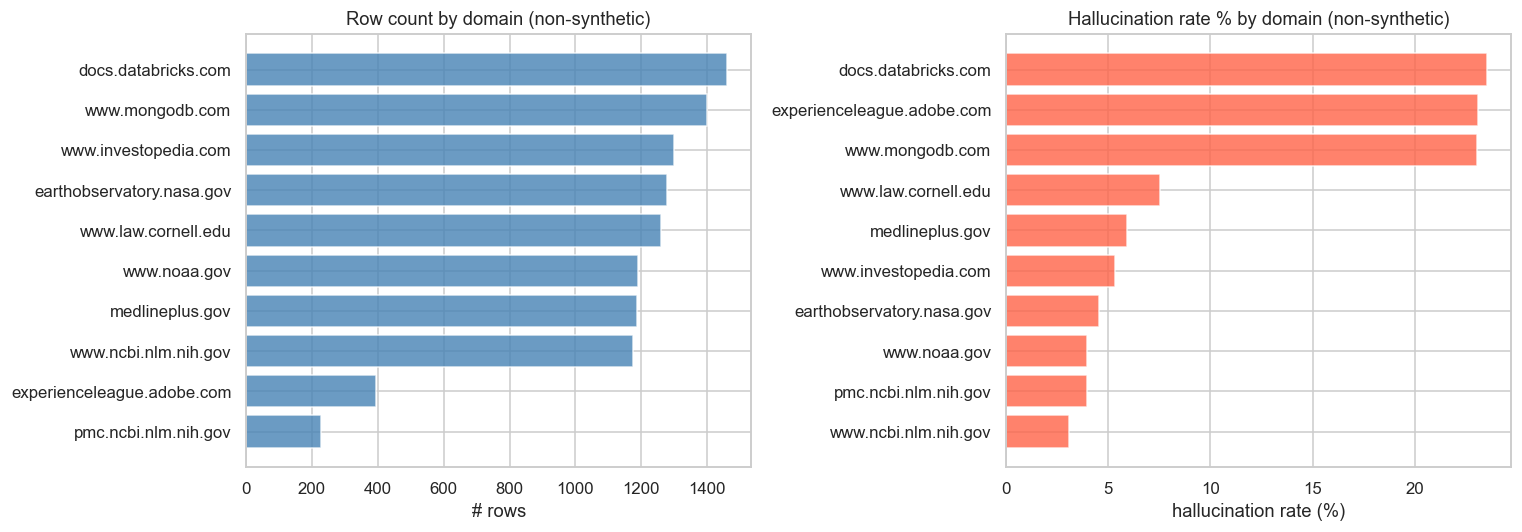

In [29]:
ns_clean["domain"] = ns_clean["website"].str.extract(r'https?://([^/]+)', expand=False).fillna("unknown")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

domain_counts = ns_clean["domain"].value_counts()
axes[0].barh(domain_counts.index, domain_counts.values, color="steelblue", alpha=0.8)
axes[0].set_title("Row count by domain (non-synthetic)")
axes[0].set_xlabel("# rows")
axes[0].invert_yaxis()

hal_rate = (ns_clean.groupby("domain")["label"]
            .apply(lambda x: (x == "hallucinated").mean() * 100)
            .sort_values(ascending=False))
axes[1].barh(hal_rate.index, hal_rate.values, color="tomato", alpha=0.8)
axes[1].set_title("Hallucination rate % by domain (non-synthetic)")
axes[1].set_xlabel("hallucination rate (%)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### B6. Word-count and token-length distributions (LibreEval)

Input text = `reference [SEP] input [SEP] output`

In [ ]:
SAMPLE_N = 1000
print("DistilBERT token lengths (n=1000 sample per split):")
libre_tok_stats = {}
for name, sub in [("non-synthetic", ns_clean), ("synthetic", syn_clean)]:
    texts = sub["input_text"].sample(min(SAMPLE_N, len(sub)), random_state=42).tolist()
    lens  = np.array([len(tokenizer.encode(t, add_special_tokens=True)) for t in texts])
    libre_tok_stats[name] = lens
    print(f"  {name:15s}  median={np.median(lens):.0f}  p95={np.percentile(lens,95):.0f}  "
          f"max={lens.max()}  >512: {(lens>512).mean()*100:.1f}%  >8192: {(lens>8192).mean()*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, lens) in zip(axes, libre_tok_stats.items()):
    ax.hist(lens, bins=60, color="steelblue", alpha=0.75, density=True)
    ax.axvline(512,  color="tomato",     linestyle="--", linewidth=1.4, label="DistilBERT (512)")
    ax.axvline(8192, color="darkorange", linestyle="--", linewidth=1.4, label="ModernBERT (8192)")
    ax.set_title(f"LibreEval {name} — DistilBERT tokens")
    ax.set_xlabel("token count")
    ax.legend(fontsize=8)

plt.suptitle("LibreEval token-length distributions (DistilBERT tokenizer)", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
SEP = " [SEP] "
ns_clean["input_text"] = ns_clean["reference"].fillna("") + SEP + ns_clean["input"].fillna("") + SEP + ns_clean["output"].fillna("")
syn_clean["input_text"] = syn_clean["reference"].fillna("") + SEP + syn_clean["input"].fillna("") + SEP + syn_clean["output"].fillna("")

ns_clean["word_count"]  = ns_clean["input_text"].str.split().str.len()
syn_clean["word_count"] = syn_clean["input_text"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, sub) in zip(axes, [("non-synthetic", ns_clean), ("synthetic", syn_clean)]):
    for lbl, color, lab in [("factual", "steelblue", "factual"), ("hallucinated", "tomato", "hallucinated")]:
        sub[sub["label"] == lbl]["word_count"].plot.hist(
            ax=ax, bins=60, alpha=0.55, density=True, color=color, label=lab
        )
    ax.set_title(f"LibreEval {name} - word count")
    ax.set_xlabel("words")
    ax.legend()

plt.tight_layout()
plt.show()

for name, sub in [("non-synthetic", ns_clean), ("synthetic", syn_clean)]:
    print(f"{name}:")
    summary = sub.groupby("label")["word_count"].agg(
        mean="mean",
        **{"50%": "median"},
        **{"95%": lambda s: s.quantile(0.95)},
        max="max",
    ).round(0)
    print(summary[["mean", "50%", "95%", "max"]])
    print()

### B7. Human-label agreement (non-synthetic only)

In [32]:
human = ns_clean[ns_clean["human_label"].notna()].copy()
print(f"Rows with human labels: {len(human)}")

agree = (human["label"] == human["human_label"]).mean() * 100
print(f"Agreement (ensemble label vs human): {agree:.1f}%")

ct = pd.crosstab(human["label"], human["human_label"], margins=True)
display(ct)

Rows with human labels: 1645
Agreement (ensemble label vs human): 97.1%


human_label,factual,hallucinated,All
label,,,
factual,1398,29,1427
hallucinated,19,199,218
All,1417,228,1645


## Cross-Dataset Comparison (Track A vs Track B)

Token statistics are printed by **A4** (HaluEval) and **B6** (LibreEval) — re-run those cells to refresh the numbers below.

| Dataset | Split | Examples | Label balance | Median tokens | >512 | >8192 |
|---|---|---|---|---|---|---|
| HaluEval | QA | 20,000 | 50/50 (paired) | ~108 | ~0% | 0% |
| HaluEval | Dialogue | 20,000 | 50/50 (paired) | ~127 | ~0% | 0% |
| HaluEval | Summarization | 20,000 | 50/50 (paired) | ~831 | ~82% | 0% |
| LibreEval | non-synthetic eval | ~10,870 | ~10% hallucinated | → B6 | → B6 | → B6 |
| LibreEval | synthetic eval | ~16,306 | ~50/50 | → B6 | → B6 | → B6 |
| LibreEval | tuning train | 18,254 | ~50/50 (balanced) | — | — | — |
| LibreEval | tuning test | 2,739 | ~50/50 (balanced) | — | — | — |

**Split recommendations:**
- **Training:** HaluEval QA + Dialogue (short inputs, perfect balance, within 512 tokens for both models) and LibreEval tuning train (pre-balanced, RAG-grounded).
- **Testing ModernBERT's long-context headroom:** HaluEval Summarization (~82% of inputs exceed DistilBERT's 512-token limit, but they still fit well within ModernBERT's 8192-token window).
- **Robustness / real-world evaluation:** LibreEval non-synthetic (~10% hallucination rate mirrors deployment conditions; multi-domain provenance tests generalization).

**Key differences from HaluEval:**
- LibreEval has **6 hallucination type** labels — valuable for fine-grained error analysis in M4.
- The non-synthetic split reflects real-world class imbalance (~10% hallucinated).
- Inputs are shorter (RAG context + short Q&A) — largely within 512 tokens.
- Multi-domain provenance (10 websites) enables domain-specific evaluation.
- Human labels available on ~1,600 rows for label-quality checks.